In [61]:
import re
import matplotlib.pyplot as plt


def parse_timing_flat(text: str) -> dict:
    pattern = r"Time for: (.+?):\s+Wall time:\s+([\d.]+)s\s+CPU time:\s+([\d.]+)s"
    matches = re.findall(pattern, text)
    return {
        f"{name}_{key}": val
        for name, wall, cpu in matches
        for key, val in [("wall_time", float(wall)), ("cpu_time", float(cpu))]
    }

    
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle

def plot_timing_boxplots(data: list[dict], title: str = "Timing Results") -> plt.Figure:
    keys = ["aggregate-zarr_wall_time", "aggregate-zarr_cpu_time"]
    colors = {"wall_time": "#4C72B0", "cpu_time": "#DD8452"}
    bg_colors = ["#f0f0f0", "#ffffff"]
    
    n_scenarios = len(data)
    
    # Collect all series and positions
    all_series = []
    positions = []
    scenario_centers = []
    scenario_names = []
    
    for i, scenario in enumerate(data):
        name = scenario["scenario_name"]
        measurements = scenario["measurement"]
        scenario_names.append(name)
        
        base_pos = i * 3
        positions.extend([base_pos, base_pos + 1])
        scenario_centers.append(base_pos + 0.5)
        
        for key in keys:
            all_series.append([m[key] for m in measurements if key in m])
    
    fig, ax = plt.subplots(figsize=(max(10, n_scenarios * 3), 6))
    
    # Create boxplot first to get y-limits
    bp = ax.boxplot(
        all_series,
        positions=positions,
        widths=0.6,
        showfliers=True,
        patch_artist=True,
        medianprops={"color": "white", "linewidth": 1.5},
        flierprops={"marker": "o", "markersize": 5, "alpha": 0.6},
        whiskerprops={"linewidth": 1.2},
        capprops={"linewidth": 1.2},
    )
    
    # Apply colors to boxes
    box_colors = [colors["wall_time"], colors["cpu_time"]] * n_scenarios
    for patch, color in zip(bp["boxes"], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
        patch.set_edgecolor("black")
        patch.set_linewidth(1.2)
    
    for flier, color in zip(bp["fliers"], box_colors):
        flier.set_markerfacecolor(color)
        flier.set_markeredgecolor("black")
    
    # Fix y-limits with padding
    all_values = [v for series in all_series for v in series]
    y_min = min(all_values)
    y_max = max(all_values)
    y_range = y_max - y_min
    y_padding = y_range * 0.1
    ax.set_ylim(max(0, y_min - y_padding), y_max + y_padding)
    
    y_min, y_max = ax.get_ylim()
    
    # Draw alternating background rectangles
    for i in range(n_scenarios):
        base_pos = i * 3
        rect = Rectangle(
            (base_pos - 0.6, y_min), 2.2, y_max - y_min,
            facecolor=bg_colors[i % 2],
            edgecolor="none",
            zorder=0,
        )
        ax.add_patch(rect)
    
    # X-axis labels
    ax.set_xticks(scenario_centers)
    ax.set_xticklabels([f"{name}\n(Wall | CPU)" for name in scenario_names], 
                       fontsize=10, fontweight="bold")
    
    # Grid and spines
    ax.yaxis.grid(True, linestyle="--", alpha=0.7)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    ax.set_ylabel("Time (s)", fontsize=12)
    ax.set_title(title, fontsize=14, fontweight="bold", pad=15)
    ax.set_xlim(-0.8, n_scenarios * 3 - 1.8)
    
    # Legend
    legend_elements = [
        Patch(facecolor=colors["wall_time"], edgecolor="black", alpha=0.7, label="Wall Time"),
        Patch(facecolor=colors["cpu_time"], edgecolor="black", alpha=0.7, label="CPU Time"),
    ]
    ax.legend(handles=legend_elements, loc="upper right", framealpha=0.9)
    
    # Sample sizes annotation
    sample_info = ", ".join(f"{s['scenario_name']}: n={len(s['measurement'])}" for s in data)
    ax.text(0.02, 0.98, sample_info, transform=ax.transAxes, fontsize=9,
            verticalalignment="top", style="italic", color="#666666")
    
    fig.tight_layout()
    plt.close(fig)
    return fig

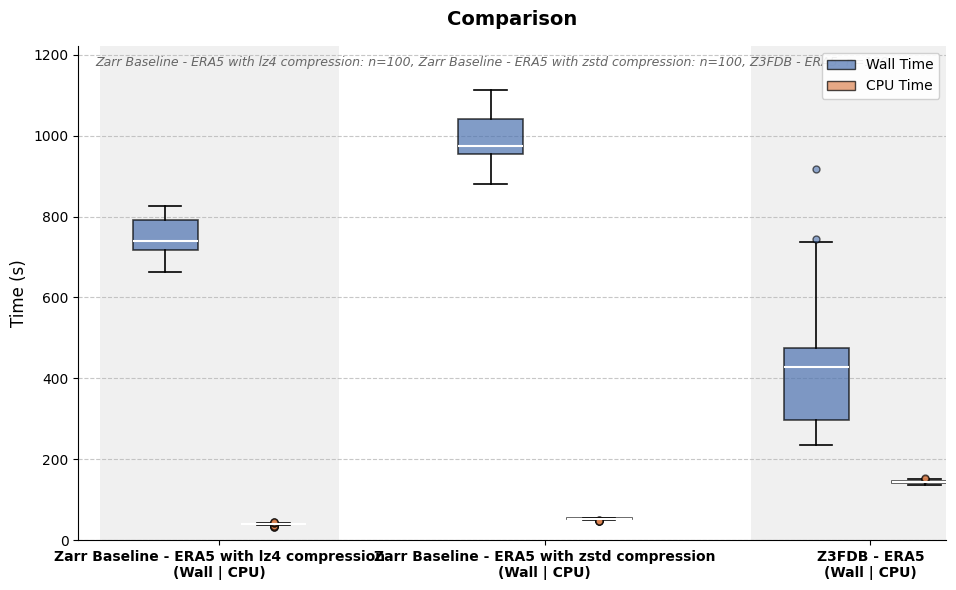

In [62]:
from sites.sdk.sites import Site, Authenticator
from sites.sdk.sites.utils import FileType

token = "7xatya6MqDC5KoauyjrT7XdzROO6BUJvahz2dEGh3N6zbyu9Ae8g4b1ZDTIPItFvuYLeWopY6CBynK1Anu24Rf5NOhbu95j44liz6DL3yoxHsdaxCSJ4Gu5T"
runs = [
    {"path":"benchmark-zarr-lz_36495834", "name":"Zarr Baseline - ERA5 with lz4 compression"},
    {"path":"benchmark-zarr-zstd_36530441", "name":"Zarr Baseline - ERA5 with zstd compression"},
    {"path":"benchmar-z3fdb_36484912", "name":"Z3FDB - ERA5"},
]

site = Site(space="ecm7593", name="z3fdb")

measurements = []
content_manager = site.get_content_manager(authenticator=Authenticator.from_token(token=token))
for run in runs:
    files = content_manager.list_walk(remote_path=run["path"], file_type=FileType.FILE, recursive=True)
    measurements.append({"scenario_name":run["name"], "measurement":[]})
    for item in files:
        if item["type"] != "f":
            continue
        path = f"{run['path']}/{item['path']}"
        log = content_manager.download(path)
        measurements[-1]["measurement"].append(parse_timing_flat(log.decode("utf-8")))

#print(measurements)
plot_timing_boxplots(measurements, "Comparison")    